# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

# Сезони Індії за місяцями
# 1 = Winter, 2 = Summer, 3 = Monsoon, 4 = Post-Monsoon

season_num_map_india = {
    12: 1, 1: 1, 2: 1,          # Winter
    3: 2, 4: 2, 5: 2,           # Summer
    6: 3, 7: 3, 8: 3, 9: 3,     # Monsoon
    10: 4, 11: 4                # Post-Monsoon
}

df['weather_season_india'] = df['month'].map(season_num_map_india)

# Текстові назви сезонів
season_name_map_india = {
    1: 'Winter',
    2: 'Summer',
    3: 'Monsoon',
    4: 'Post-Monsoon'
}

df['weather_season_india_name'] = df['weather_season_india'].map(season_name_map_india)


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df['month_year'] = df.index.to_period('M')
df['month_year'] = df.month_year.astype(str)

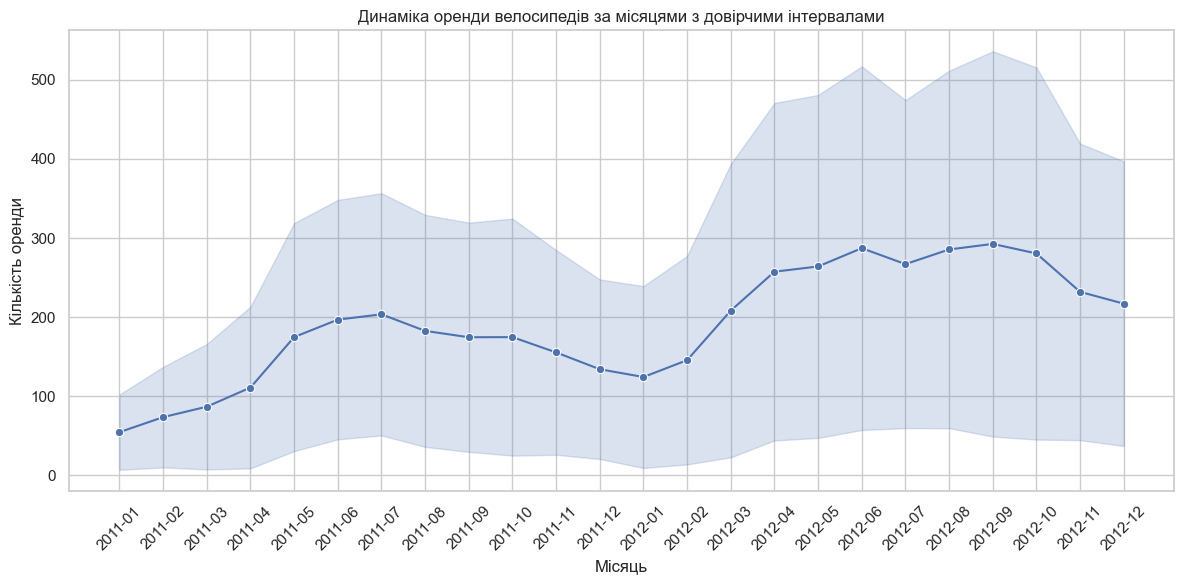

In [3]:
plt.figure(figsize=(12, 6))

sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45)
plt.tight_layout();

Найбільша варіативність даних спостерігається у 2012 році, приблизно з квітня по листопад, оскільки саме в цей період інтервал ±1 стандартного відхилення є найширшим. Це свідчить про те, що кількість оренд у ці місяці змінювалася найбільше.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

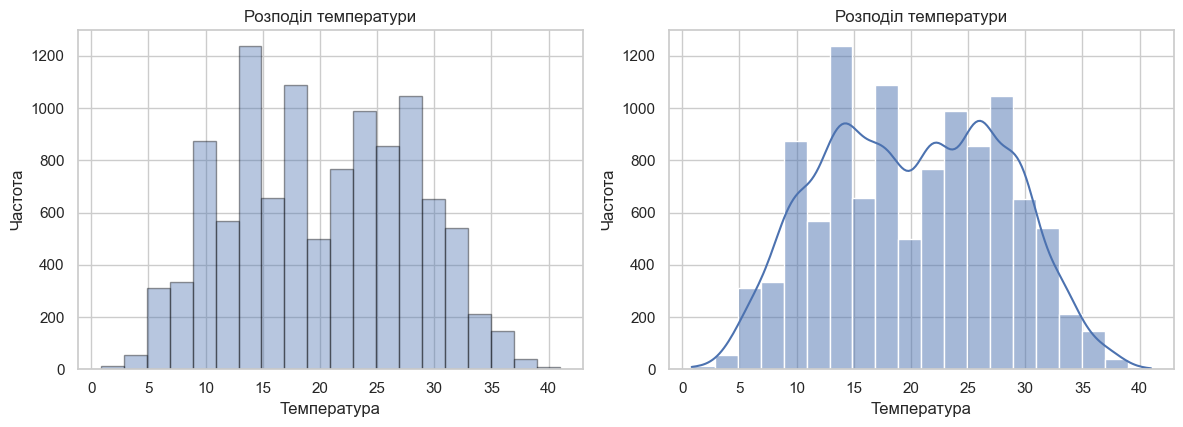

In [4]:
plt.figure(figsize=(12, 8))

#Графік Pandas
plt.subplot(2, 2, 1)
df['temp'].plot.hist(
    bins=20,
    alpha=0.4,
    edgecolor='black',
    title='Розподіл температури',
    xlabel='Температура',
    ylabel='Частота' 
)

#Графік Seaborn
plt.subplot(2, 2, 2)
sns.histplot(df['temp'], bins=20, kde=True)
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

У Pandas гістограма виглядає простіше і більш “класично” — видно лише стовпчики частот.

У Seaborn гістограма виглядає більш гладко та візуально сучасніше. Додаткова лінія на графіку — це KDE-крива, тобто згладжене відображення розподілу даних. Вона допомагає краще побачити, де зосереджено найбільше значень температури та як загалом виглядає форма розподілу.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

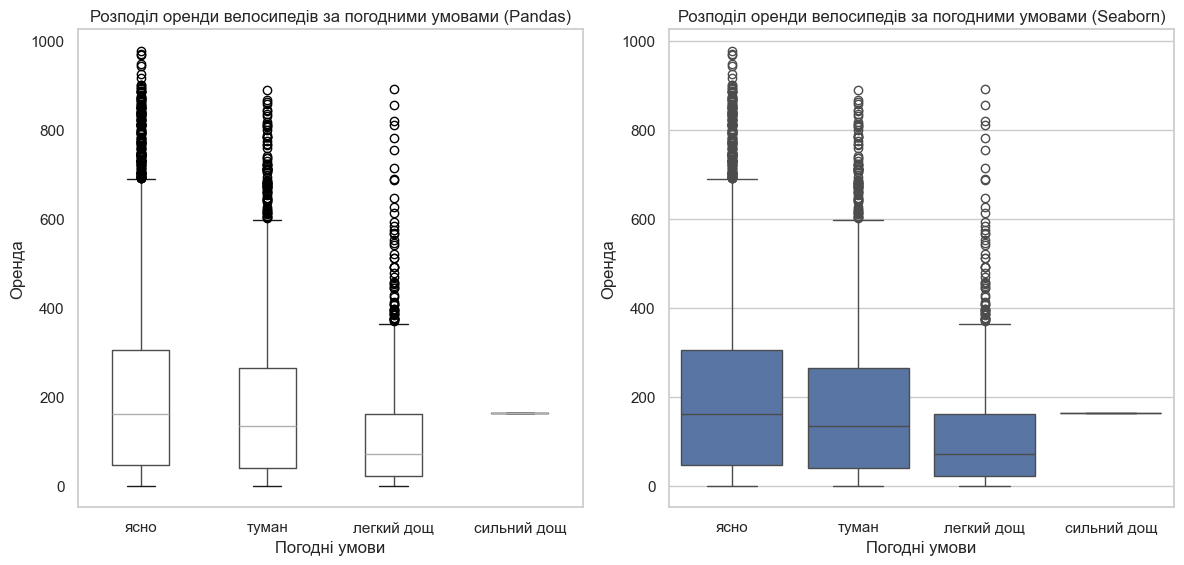

In [5]:
plt.figure(figsize=(12, 6))

#Графік Pandas
ax1 = plt.subplot(1, 2, 1)
df.boxplot(column='count', by='weather', grid=False, ax=ax1)
plt.title('Розподіл оренди велосипедів за погодними умовами (Pandas)')
plt.suptitle('')  # Видаляємо автоматичний заголовок
plt.xlabel('Погодні умови')
plt.ylabel('Оренда')
plt.xticks([1, 2, 3, 4], ['ясно', 'туман', 'легкий дощ', 'сильний дощ'])

#Графік Seaborn
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='weather', y='count')
plt.title('Розподіл оренди велосипедів за погодними умовами (Seaborn)')
plt.xlabel('Погодні умови')
plt.ylabel('Оренда')
plt.xticks([0, 1, 2, 3], ['ясно', 'туман', 'легкий дощ', 'сильний дощ'])

plt.tight_layout()
plt.show()

Візуально box plot у Pandas виглядає простіше та більш базово, без додаткового стилізування. У Seaborn графік виглядає більш сучасно та виразно завдяки кольору й оформленню.

За обома графіками видно, що найбільша кількість оренд спостерігається за ясної погоди, трохи нижча — за туману, і ще нижча — під час легкого дощу. За сильного дощу значень дуже мало, тому розподіл виглядає майже як одна лінія. Також на графіках видно викиди майже за всіх погодних умов, тобто трапляються окремі значення оренд, що суттєво відрізняються від основної маси даних.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


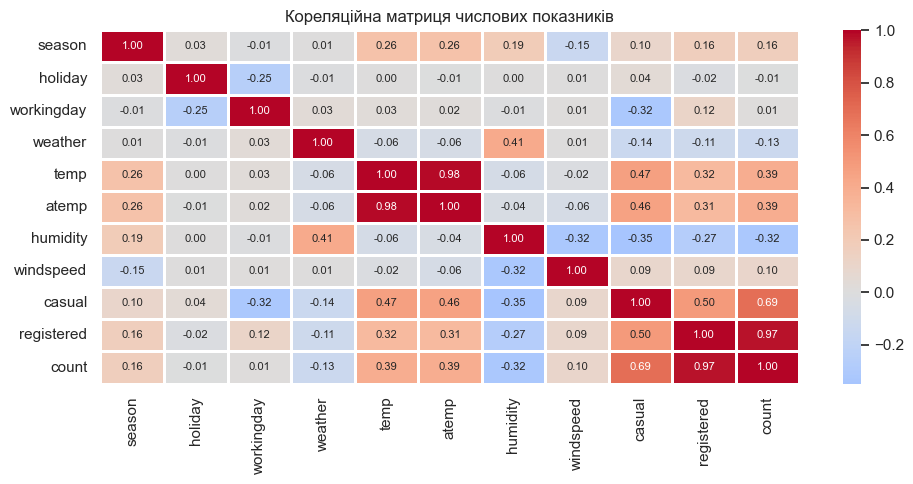

In [6]:
corr = df[['season', 'holiday', 'workingday', 'weather',
           'temp', 'atemp', 'humidity', 'windspeed',
           'casual', 'registered', 'count']].corr()

plt.figure(figsize=(10, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=1, annot_kws={'size': 8})
plt.title('Кореляційна матриця числових показників')
plt.tight_layout()
plt.show()

Найсильніше з загальною кількістю оренди (`count`) корелюють `registered` (0.97) та `casual` (0.69, кількість випадкових користувачів), що логічно, адже саме з них і складається загальна кількість оренд. Також помітна помірна позитивна кореляція з `temp` і `atemp` (по 0.39).

Між `temp` та `atemp` спостерігається дуже сильна позитивна кореляція (0.98), оскільки обидві змінні описують температуру: `temp` — фактичну, а `atemp` — температуру, яка відчувається.

Негативну кореляцію мають насамперед `humidity` і `count` (-0.32), `weather` і `count` (-0.13), а також `workingday` і `casual` (-0.32). Це означає, що зі зростанням цих показників кількість оренд або окремі типи оренд мають тенденцію зменшуватись.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


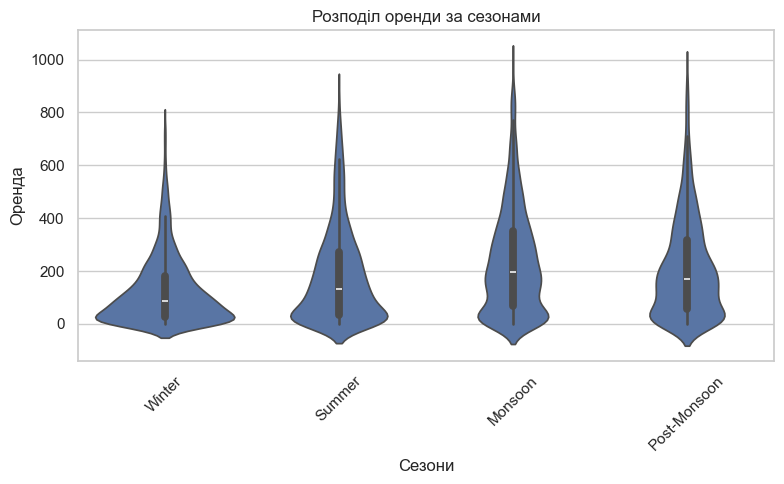

In [7]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='weather_season_india_name', y='count',
              #  order=['January', 'February', 'March', 'April', 'May', 'June',
              #         'July', 'August', 'September', 'October', 'November', 'December']
               )
plt.xticks(rotation=45)
plt.title('Розподіл оренди за сезонами')
plt.xlabel('Сезони')
plt.ylabel('Оренда')
plt.tight_layout()
plt.show()

"Товщина" violin plot показує щільність даних: чим ширший графік у певному місці, тим більше значень зосереджено в цьому діапазоні.

Найбільша варіабельність оренди спостерігається в сезоні Monsoon, оскільки саме там розподіл є найширшим і найвищим. Досить великий розкид також видно в Post-Monsoon.

Перевага violin plot над звичайним box plot у тому, що він показує не тільки медіану та квартилі, а й форму розподілу даних. Завдяки цьому краще видно, де значення зосереджені щільніше, а де розподіл більш розтягнутий.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

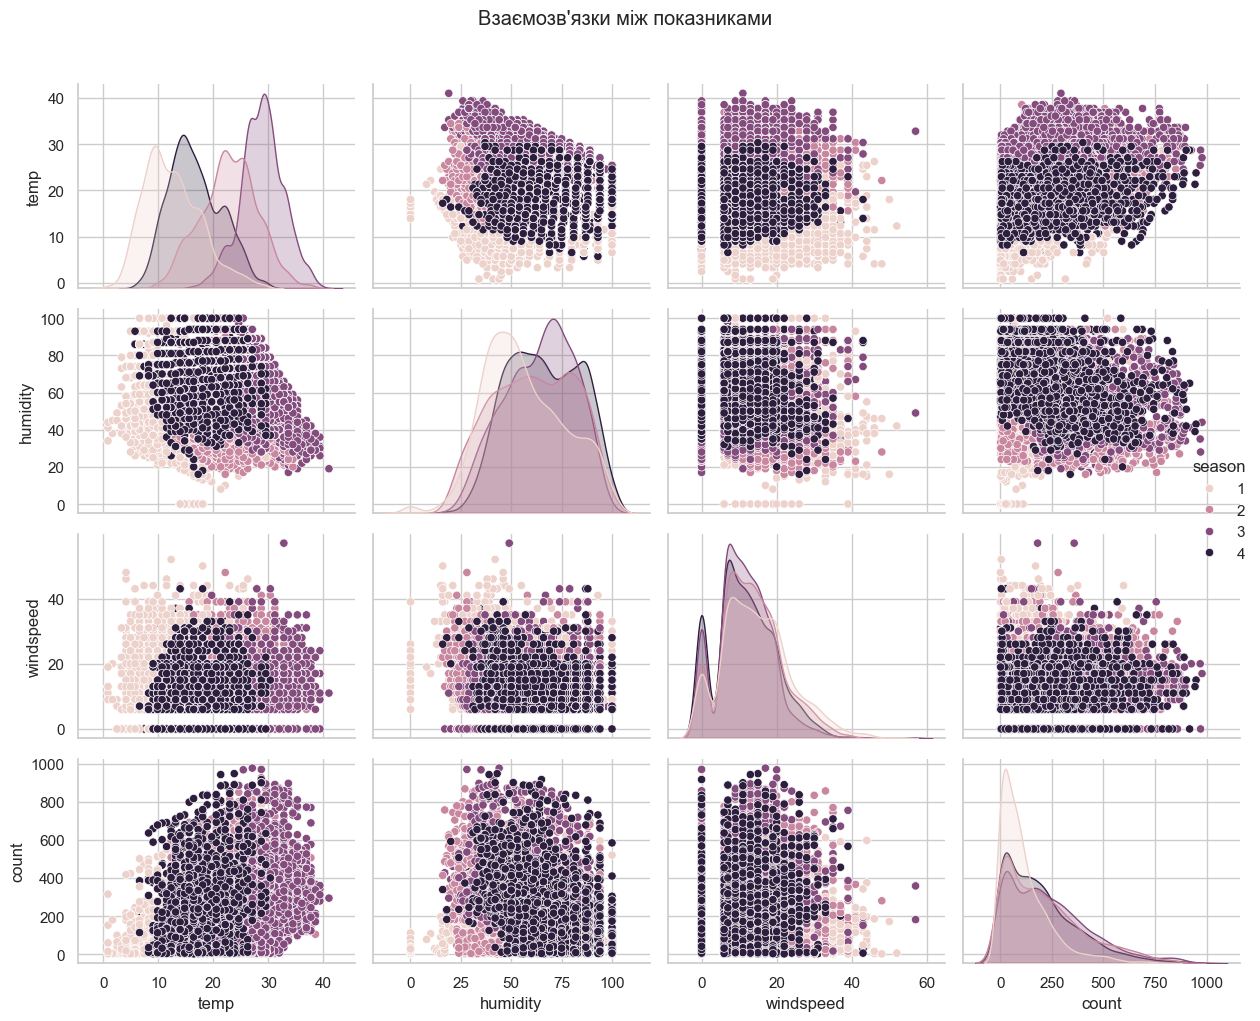

In [8]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(sample_df, hue='season', height=2.5, aspect=1.2)
plt.suptitle("Взаємозв'язки між показниками", y=1.02)
plt.tight_layout()
plt.show()

Найсильніший лінійний зв’язок спостерігається між `temp` і `count`: зі зростанням температури загальна кількість оренд також має тенденцію зростати.

Найбільше між кварталами відрізняється `count`, оскільки кількість оренд найбільш чутлива до сезонності, температури та погодних умов.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

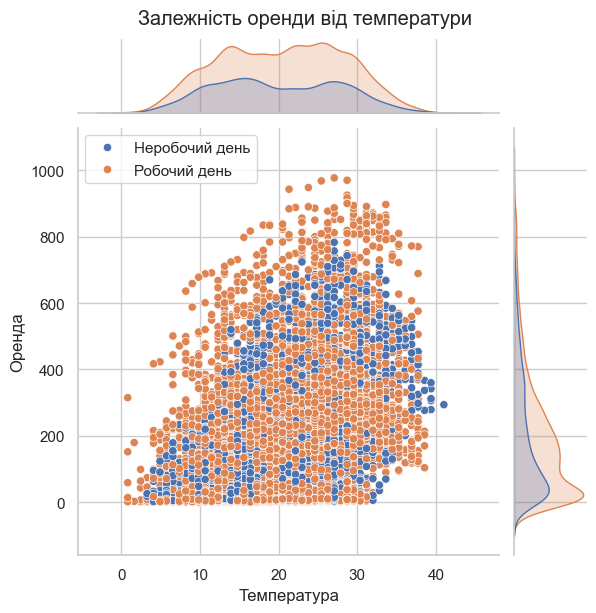

In [9]:
df['workingday_label'] = df['workingday'].map({
    0: 'Неробочий день',
    1: 'Робочий день'
})

g = sns.jointplot(data=df, x='temp', y='count', hue='workingday_label')
g.fig.suptitle('Залежність оренди від температури', y=1.02)
g.set_axis_labels('Температура', 'Оренда')
g.ax_joint.legend(title='');

Графіки по краях показують розподіл змінних окремо: зверху — температури, праворуч — оренди.

Між робочими й неробочими днями є різниця: у робочі дні кількість оренд загалом вища. Також видно, що зі зростанням температури оренда частіше збільшується.

**Time spent — 4 години**

**What I learned:**
- Навчилася будувати статистичні графіки в **Seaborn**: `lineplot`, `histplot`, `boxplot`, `heatmap`, `violinplot`, `pairplot`, `jointplot`.
- Побачила різницю між **Pandas** і **Seaborn**: Pandas — простіше для базових графіків, Seaborn — краще для статистичного аналізу та оформлення.
- Практикувала **роботу з категоріями**: порядок сезонів, підписи погодних умов, зрозуміла робота з `hue` і легендами.
- Навчилася **читати кореляції та розподіли**: знаходити сильні зв’язки, негативні кореляції, варіабельність, викиди та щільність даних.
- Закріпила **оформлення графіків**: заголовки, підписи осей, `kde`, `annot`, прозорість, `tight_layout()` і читабельність візуалізацій.
- Краще розібралася з типовими помилками в **Jupyter Notebook** під час побудови графіків і способами їх виправлення.